<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/DS/lamp/Lamp_spectrum_measurements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectrum of LEDs measured by spectrograph

Evgeny Kolonsky, 2026

v.0.1.1

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal import find_peaks, peak_widths
from scipy.interpolate import PchipInterpolator

Auxillary functions

In [7]:
def get_data(name):
  url = URL.format(**locals())
  waves, sample, dark = np.loadtxt(url, delimiter=';', skiprows=8, usecols=[0,1,2], unpack=True)
  counts = sample - dark
  return waves, counts



# Matrix spectral sensitivity

Sotce: https://spectrecology.com/wp-content/uploads/2021/03/SONY-ILX511B.pdf

When Sensituvity $R(\lambda) < 0.05$ is small, consider data as unreliable.

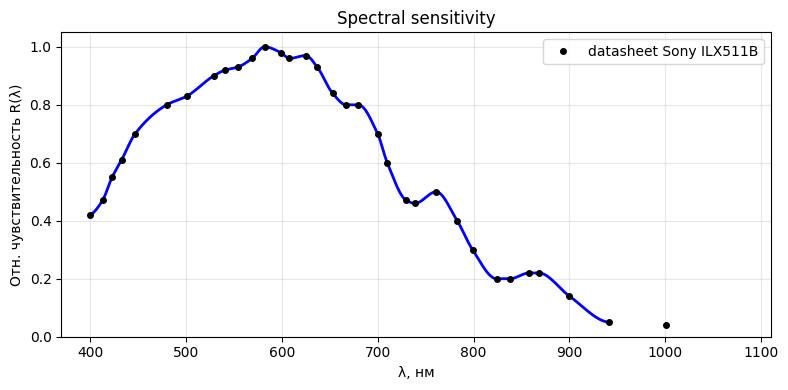

In [8]:
# Digitized Sony ILX511B sensitivity data
data = '''
# x	 y
400	0.42
413	0.47
423	0.55
433	0.61
447	0.70
480	0.80
501	0.83
529	0.90
541	0.92
554	0.93
569	0.96
582	1.00
599	0.98
608	0.96
625	0.97
637	0.93
653	0.84
667	0.80
680	0.80
700	0.70
710	0.60
730	0.47
739	0.46
761	0.50
783	0.40
799	0.30
824	0.20
838	0.20
858	0.22
868	0.22
900	0.14
941	0.05
1001	0.04
'''
ilx511_lam_nm,  ilx511_resp = np.genfromtxt(data.splitlines(),  unpack=True)
R_interp = PchipInterpolator(ilx511_lam_nm, ilx511_resp, extrapolate=False)

def R_lambda(lam_nm, threshold=0.05):
    # Relative sensitivity R(λ) (nm).
    r = R_interp(lam_nm)
    r_safe = np.where(r > threshold, r, np.nan)
    return r_safe

plt.figure(figsize=(8, 4))
lam_dense = np.linspace(380, 1100, 800)
plt.plot(lam_dense, R_lambda(lam_dense), 'b-', lw=2)
plt.plot(ilx511_lam_nm, ilx511_resp, 'ko', ms=4, label='datasheet Sony ILX511B')
plt.xlabel('λ, нм'); plt.ylabel('Отн. чувствительность R(λ)')
plt.title('Spectral sensitivity')
plt.grid(alpha=0.3); plt.legend()
plt.xlim(370, 1110); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()


# Raw spectral data

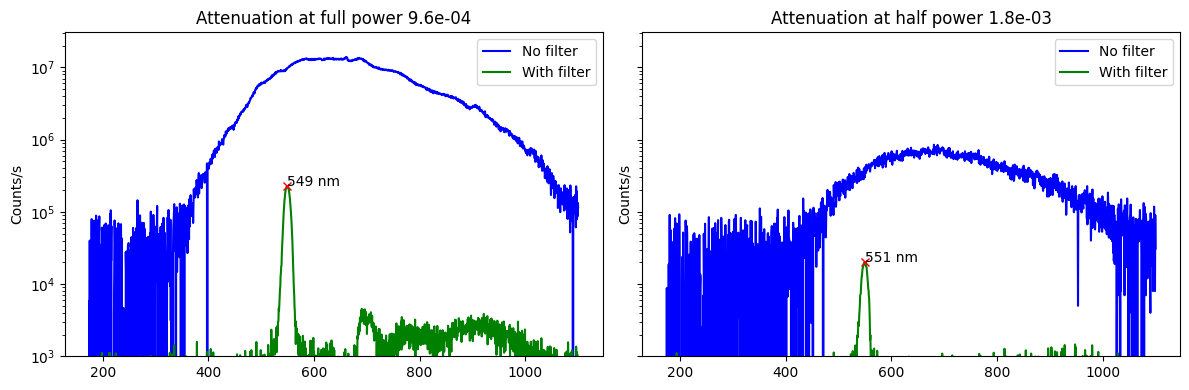

In [9]:
URL =  'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/DS/lamp/{name}.txt'


fig, axs = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True, sharey=True)


ax = axs[0]

name = 'no-filter-1ms-full-range'
waves, counts = get_data(name)
gain = 1e-3
counts /= gain
S0 = np.sum(counts)
ax.plot(waves, counts, color='blue', label='No filter')

name = 'filter-100ms-full-range'
waves, counts = get_data(name)
gain = 100e-3
counts /= gain
S_filter = np.sum(counts)
ax.plot(waves, counts, color='green', label='With filter')
locs, _ = find_peaks(counts, prominence=1e5)
ax.plot(waves[locs], counts[locs], 'x', color='red')
ax.annotate(f'{waves[locs[0]]:.0f} nm', (waves[locs[0]], counts[locs[0]]))

factor = S_filter / S0

ax.set_yscale('log')
ax.set_ylim(bottom=1e3)
ax.set_title(f'Attenuation at full power {factor:.1e}')
ax.set_ylabel('Counts/s')
ax.legend()

ax = axs[1]

name = 'no-filter-1ms-half-range'
waves, counts = get_data(name)
gain = 1e-3
counts /= gain
S0 = np.sum(counts)
ax.plot(waves, counts, color='blue', label='No filter')

name = 'filter-100ms-half-range'
waves, counts = get_data(name)
gain = 100e-3
counts /= gain
S_filter = np.sum(counts)
ax.plot(waves, counts, color='green', label='With filter')
locs, _ = find_peaks(counts, prominence=1e4)
ax.plot(waves[locs], counts[locs], 'x', color='red')
ax.annotate(f'{waves[locs[0]]:.0f} nm', (waves[locs[0]], counts[locs[0]]))

factor = S_filter / S0

ax.set_yscale('log')
ax.set_ylim(bottom=1e3)
ax.set_title(f'Attenuation at half power {factor:.1e}')
ax.set_ylabel('Counts/s')
ax.legend()





# Spectral sensitivity correction

True counts = Observed counts / Sensitivity



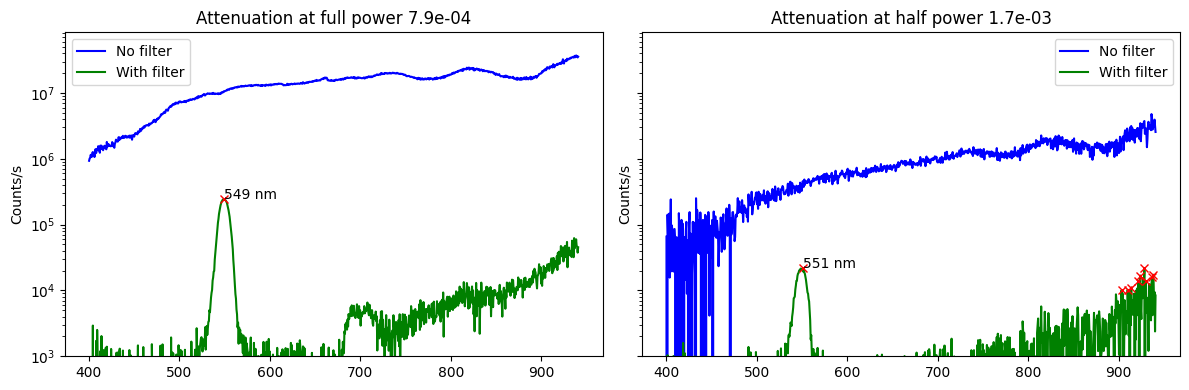

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True, sharey=True)


ax = axs[0]

name = 'no-filter-1ms-full-range'
waves, counts = get_data(name)
gain = 1e-3
counts /= gain
counts /= R_lambda(waves)
S0 = np.nansum(counts)
ax.plot(waves, counts, color='blue', label='No filter')

name = 'filter-100ms-full-range'
waves, counts = get_data(name)
gain = 100e-3
counts /= gain
counts /= R_lambda(waves)
S_filter = np.nansum(counts)
ax.plot(waves, counts, color='green', label='With filter')
locs, _ = find_peaks(counts, prominence=1e5)
ax.plot(waves[locs], counts[locs], 'x', color='red')
ax.annotate(f'{waves[locs[0]]:.0f} nm', (waves[locs[0]], counts[locs[0]]))

factor = S_filter / S0

ax.set_yscale('log')
ax.set_ylim(bottom=1e3)
ax.set_title(f'Attenuation at full power {factor:.1e}')
ax.set_ylabel('Counts/s')
ax.legend()

ax = axs[1]

name = 'no-filter-1ms-half-range'
waves, counts = get_data(name)
gain = 1e-3
counts /= gain
counts /= R_lambda(waves)
S0 = np.nansum(counts)
ax.plot(waves, counts, color='blue', label='No filter')

name = 'filter-100ms-half-range'
waves, counts = get_data(name)
gain = 100e-3
counts /= gain
counts /= R_lambda(waves)
S_filter = np.nansum(counts)
ax.plot(waves, counts, color='green', label='With filter')
locs, _ = find_peaks(counts, prominence=1e4)
ax.plot(waves[locs], counts[locs], 'x', color='red')
ax.annotate(f'{waves[locs[0]]:.0f} nm', (waves[locs[0]], counts[locs[0]]))

factor = S_filter / S0

ax.set_yscale('log')
ax.set_ylim(bottom=1e3)
ax.set_title(f'Attenuation at half power {factor:.1e}')
ax.set_ylabel('Counts/s')
ax.legend()




